# FullCI Temporal Causal Discovery Analysis

This notebook runs FullCI (conditioning on the whole past) across a range of tau (maximum lag) values on simulated datasets to assess sensitivity to lag depth.

## Objective
- Simulate 10 trials for each tau value (1 to 7)
- Test FullCI for temporal causal discovery with varying maximum lag
- Collect performance metrics (accuracy, precision, recall, F1, etc.)
- Compare performance across different conditioning depths

## Configuration
- **Trials per tau**: 10
- **Tau range**: 1 to 7 (maximum lag to consider)
- **Network size**: 18-29 variables per trial
- **Time series length**: 5000-9999 timesteps per trial
- **Method**: FullCI (Tigramite implementation)

In [1]:
# Setup and imports
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
import sys

# Locate project root
PROJECT_ROOT = next(
    (p for p in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
    if (p / "src" / "markovianity_diagnostic").exists()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not locate project root")

SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from markovianity_diagnostic.core.utils import adj_mtx,  continuous_noise_fun

# Import FullCI from tigramite
import tigramite
from tigramite import data_processing as pp
from tigramite.pcmci import PCMCI
from tigramite.independence_tests.parcorr import ParCorr

print("✓ All imports successful")
print(f"Project root: {PROJECT_ROOT}")

✓ All imports successful
Project root: /Users/sadiqadedayo/Documents/projects/Detecting Latent confounders with Markovianity/hidden-confounding-diagnostics


In [2]:
# Configuration
NUM_TRIALS = 10
SEED = 42
np.random.seed(SEED)

# FullCI hyperparameters
TAU_MIN = 1
TAU_MAX = 7
TAU_RANGE = list(range(TAU_MIN, TAU_MAX + 1))

OUTPUT_DIR = PROJECT_ROOT / 'data' / 'outputs' / 'fullci_results' / 'singleLag-NonMarkovian'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Configuration:")
print(f"  Trials per tau: {NUM_TRIALS}")
print(f"  Tau range: {TAU_RANGE}")
print(f"  Output dir: {OUTPUT_DIR}")

Configuration:
  Trials per tau: 10
  Tau range: [1, 2, 3, 4, 5, 6, 7]
  Output dir: /Users/sadiqadedayo/Documents/projects/Detecting Latent confounders with Markovianity/hidden-confounding-diagnostics/data/outputs/fullci_results/singleLag-NonMarkovian


In [3]:
def recovery_metrics(predicted: np.ndarray, truth: np.ndarray) -> dict[str, float]:
    """Compute accuracy, precision, recall, FPR, balanced_accuracy, F1 for binary adjacencies."""
    predicted = (predicted > 0).astype(int)
    truth = (truth > 0).astype(int)

    # Zero diagonals
    np.fill_diagonal(predicted, 0)
    np.fill_diagonal(truth, 0)

    tp = int(np.logical_and(predicted == 1, truth == 1).sum())
    tn = int(np.logical_and(predicted == 0, truth == 0).sum())
    fp = int(np.logical_and(predicted == 1, truth == 0).sum())
    fn = int(np.logical_and(predicted == 0, truth == 1).sum())

    total = tp + tn + fp + fn
    accuracy = (tp + tn) / total if total else 0.0
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    fpr = fp / (fp + tn) if (fp + tn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0
    balanced_accuracy = (specificity + recall) / 2
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) else 0.0

    return {
        'accuracy': float(accuracy),
        'precision': float(precision),
        'recall': float(recall),
        'fpr': float(fpr),
        'balanced_accuracy': float(balanced_accuracy),
        'f1': float(f1),
        'tp': float(tp),
        'fp': float(fp),
        'tn': float(tn),
        'fn': float(fn),
    }

def graph_to_adjacency(causal_graph) -> np.ndarray:
    """Convert a Tigramite FullCI graph to a binary adjacency matrix.

    Any directed edge at any lag is treated as present in the collapsed adjacency.
    """
    n_vars = causal_graph.shape[0]
    adjacency = np.zeros((n_vars, n_vars), dtype=int)

    for source in range(causal_graph.shape[0]):
        for target in range(causal_graph.shape[1]):
            for lag in range(causal_graph.shape[2]):
                edge_type = causal_graph[source, target, lag]
                if isinstance(edge_type, str) and '>' in edge_type and '<' not in edge_type:
                    adjacency[target, source] = 1

    return adjacency

print("✓ Helper functions defined")

✓ Helper functions defined


In [4]:
# Run FullCI across tau range for 10 trials (samples)
# Structure: outer loop over samples, inner loop over tau values
all_results = []

for trial_id in tqdm(range(NUM_TRIALS), desc="FullCI samples"):
    # Generate data once per sample
    n_neur = np.random.randint(18, 30, 1)[0]
    l = np.random.randint(5000, 10000, 1)[0]

    noise = continuous_noise_fun(num=n_neur,l=l)

    # Simulate data
    A = adj_mtx(n_neur)
    X = np.zeros((A.shape[0], l)).T
    X[0] = np.random.randn(A.shape[0])
    for i, row in enumerate(X[:-1]):
        X[i+1] = A @ X[i] + np.random.normal(0, 0.25, A.shape[0]) + noise[:, i]
    X = X.T  # Shape: (n_neur, l)

    # Metrics array for this sample across all tau values
    trial_metrics = np.zeros((len(TAU_RANGE), 6))

    try:
        for k, tau in enumerate(TAU_RANGE):
            # Run FullCI with the current tau value
            dataframe = pp.DataFrame(X.T)
            pcmci = PCMCI(dataframe=dataframe, cond_ind_test=ParCorr(), verbosity=0)
            results_fullci = pcmci.run_fullci(tau_max=tau)

            # Extract graph (contemporaneous + lagged structure)
            causal_graph = results_fullci['graph']

            # Collapse lagged and contemporaneous directed edges into a binary adjacency
            adjacency_pred = np.zeros((n_neur, n_neur), dtype=int)
            for source in range(causal_graph.shape[0]):
                for target in range(causal_graph.shape[1]):
                    for lag in range(causal_graph.shape[2]):
                        edge_type = causal_graph[source, target, lag]
                        if isinstance(edge_type, str) and '>' in edge_type and '<' not in edge_type:
                            adjacency_pred[target, source] = 1

            np.fill_diagonal(adjacency_pred, 0)

            # Compute metrics
            metrics_dict = recovery_metrics(adjacency_pred, A)

            # Store metrics in order: accuracy, precision, recall, fpr, balanced_accuracy, f1
            trial_metrics[k] = [
                metrics_dict['accuracy'],
                metrics_dict['precision'],
                metrics_dict['recall'],
                metrics_dict['fpr'],
                metrics_dict['balanced_accuracy'],
                metrics_dict['f1']
            ]

    except Exception as e:
        print(f"Sample {trial_id} failed: {e}")
        continue

    all_results.append(trial_metrics)
    print(f"Sample {trial_id} completed with {n_neur} variables, {l} timesteps")

# Convert to numpy array: shape (NUM_TRIALS, len(TAU_RANGE), 6)
all_results_array = np.array(all_results)
print(f"\n✓ Completed {all_results_array.shape[0]} samples across {len(TAU_RANGE)} tau values")
print(f"Results shape: {all_results_array.shape}")

FullCI samples:  10%|█         | 1/10 [50:19<7:32:52, 3019.12s/it]

Sample 0 completed with 24 variables, 5860 timesteps


FullCI samples:  20%|██        | 2/10 [1:20:51<5:09:30, 2321.33s/it]

Sample 1 completed with 22 variables, 5267 timesteps


FullCI samples:  30%|███       | 3/10 [2:26:17<5:56:17, 3053.92s/it]

...

Sample 7 completed with 28 variables, 8740 timesteps


FullCI samples:  90%|█████████ | 9/10 [7:35:23<52:05, 3125.03s/it]  

Sample 8 completed with 20 variables, 7965 timesteps


FullCI samples: 100%|██████████| 10/10 [7:47:42<00:00, 2806.30s/it]

Sample 9 completed with 18 variables, 6192 timesteps

✓ Completed 10 samples across 7 tau values
Results shape: (10, 7, 6)


In [5]:
# Convert to results dataframe for export
results_list = []
metric_order = ['accuracy', 'precision', 'recall', 'fpr', 'balanced_accuracy', 'f1']

for trial_id, trial_metrics in enumerate(all_results_array):
    for tau_idx, tau in enumerate(TAU_RANGE):
        result_dict = {
            'trial_id': trial_id,
            'tau': tau
        }
        for metric_idx, metric_name in enumerate(metric_order):
            result_dict[metric_name] = trial_metrics[tau_idx, metric_idx]
        results_list.append(result_dict)

results_df = pd.DataFrame(results_list)
results_df.to_csv(OUTPUT_DIR / 'fullci_results.csv', index=False)

# Aggregate by tau: mean and std across samples
metric_names = ['accuracy', 'precision', 'recall', 'fpr', 'balanced_accuracy', 'f1']
aggregated = {}

for tau_idx, tau in enumerate(TAU_RANGE):
    aggregated[tau] = {}
    for metric_idx, metric_name in enumerate(metric_names):
        metric_values = all_results_array[:, tau_idx, metric_idx]
        aggregated[tau][metric_name] = {
            'mean': float(np.round(np.mean(metric_values), 4)),
            'std': float(np.round(np.std(metric_values), 4))
        }

print("✓ Results aggregated by tau value")
print(f"\nTau range: {TAU_RANGE}")
print(f"Number of samples: {all_results_array.shape[0]}")

# Display aggregated statistics as a table
print("\nAggregated Results: Mean ± Std Across {0} Samples per Tau".format(all_results_array.shape[0]))
print("=" * 100)
print(f"{'tau':<6} {'Accuracy':<18} {'Precision':<18} {'Recall':<18} {'F1':<18}")
print("-" * 100)
for tau in TAU_RANGE:
    agg = aggregated[tau]
    acc = f"{agg['accuracy']['mean']:.4f}±{agg['accuracy']['std']:.4f}"
    prec = f"{agg['precision']['mean']:.4f}±{agg['precision']['std']:.4f}"
    rec = f"{agg['recall']['mean']:.4f}±{agg['recall']['std']:.4f}"
    f1 = f"{agg['f1']['mean']:.4f}±{agg['f1']['std']:.4f}"
    print(f"{tau:<6} {acc:<18} {prec:<18} {rec:<18} {f1:<18}")

# Save aggregated results
with open(OUTPUT_DIR / 'fullci_aggregated.json', 'w') as f:
    aggregated_json = {str(tau): aggregated[tau] for tau in TAU_RANGE}
    json.dump(aggregated_json, f, indent=2)

print(f"\nResults saved to {OUTPUT_DIR}")

✓ Results aggregated by tau value

Tau range: [1, 2, 3, 4, 5, 6, 7]
Number of samples: 10

Aggregated Results: Mean ± Std Across 10 Samples per Tau
tau    Accuracy           Precision          Recall             F1                
----------------------------------------------------------------------------------------------------
1      0.5871±0.0529      0.1569±0.0337      0.9983±0.0052      0.2697±0.0512     
2      0.7106±0.0478      0.2100±0.0417      1.0000±0.0000      0.3451±0.0565     
3      0.7265±0.0386      0.2189±0.0416      1.0000±0.0000      0.3572±0.0573     
4      0.7319±0.0239      0.2204±0.0355      1.0000±0.0000      0.3598±0.0493     
5      0.7396±0.0218      0.2249±0.0334      1.0000±0.0000      0.3660±0.0456     
6      0.7278±0.0175      0.2175±0.0344      1.0000±0.0000      0.3559±0.0483     
7      0.7098±0.0148      0.2065±0.0323      1.0000±0.0000      0.3411±0.0458     

Results saved to /Users/sadiqadedayo/Documents/projects/Detecting Latent confounders w

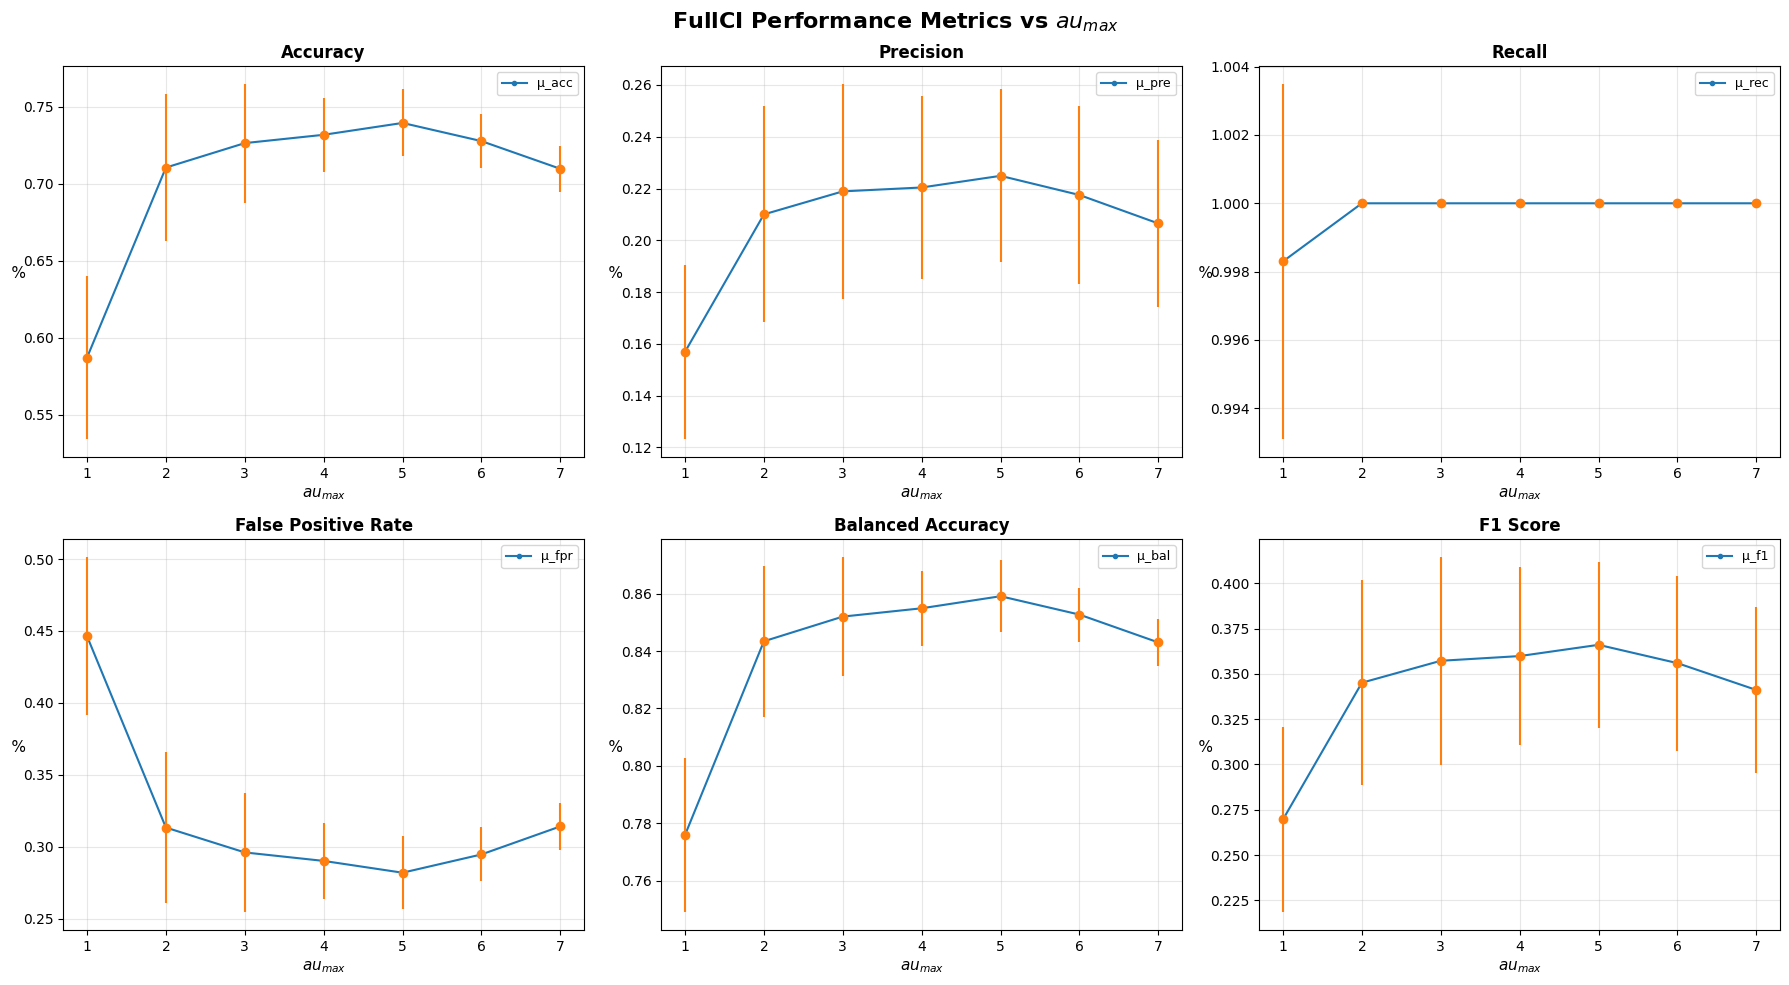

✓ Plot saved to /Users/sadiqadedayo/Documents/projects/Detecting Latent confounders with Markovianity/hidden-confounding-diagnostics/data/outputs/fullci_results/singleLag-NonMarkovian/fullci_metrics.png


In [7]:
# Prepare data for visualization by tau
data_by_metric = {}
for metric in metric_names:
    means = [aggregated[tau][metric]['mean'] for tau in TAU_RANGE]
    stds = [aggregated[tau][metric]['std'] for tau in TAU_RANGE]
    data_by_metric[metric] = {'mean': means, 'std': stds}

# Create visualization matching varLags_Markovian style
fig, ax = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('FullCI Performance Metrics vs $\tau_{max}$', fontsize=16, fontweight='bold')

metric_labels = {
    'accuracy': 'Accuracy',
    'precision': 'Precision',
    'recall': 'Recall',
    'fpr': 'False Positive Rate',
    'balanced_accuracy': 'Balanced Accuracy',
    'f1': 'F1 Score'
}

ax = ax.flatten()
for idx, metric in enumerate(metric_names):
    axis = ax[idx]
    means = data_by_metric[metric]['mean']
    stds = data_by_metric[metric]['std']

    axis.plot(TAU_RANGE, means, marker='.', label=f'μ_{metric[:3]}')
    axis.errorbar(TAU_RANGE, means, yerr=stds, fmt='o')

    axis.set_xticks(TAU_RANGE)
    axis.set_xlabel('$\tau_{max}$', fontsize=11)
    axis.set_ylabel('%', fontsize=11, rotation=180)
    axis.set_title(metric_labels[metric], fontsize=12, fontweight='bold')
    axis.grid(True, alpha=0.3)
    axis.legend(fontsize=9)

    # Set appropriate y-axis limits
    # if metric == 'fpr':
    #     axis.set_ylim([0, 0.15])
    # else:
    #     axis.set_ylim([0.4, 1.0])

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fullci_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Plot saved to {OUTPUT_DIR / 'fullci_metrics.png'}")